## Partie 3 : Prédiction de la reconnaissance CatNat pour la sécheresse

L'objectif de ce troisième chapitre est de concevoir un modèle prédictif capable d'anticiper la reconnaissance administrative de l'état de Catastrophe Naturelle (CatNat) au niveau communal.

En croisant les indicateurs de sécheresse météorologique (SWI) avec la sensibilité géologique des sols (Argile) et les données historiques de la CCR, cette analyse vise à identifier les facteurs déclenchants des arrêtés interministériels. La finalité est de distinguer la réalité physique du stress hydrique de la décision politique finale, tout en évaluant la performance d'un classifieur XGBoost pour détecter les communes les plus vulnérables.

**Aggregation des données par communes et années**

In [1]:
import pandas as pd
import geopandas as gpd

base_complete = gpd.read_parquet("base_complete.geoparquet")

# 1. Création des indicateurs annuels par commune (agrégation)
# On suppose que 'base_complete' contient vos données fusionnées avec DATE_quot et SWI_UNIF_MENS
base_complete['ANNEE'] = base_complete['DATE_quot'].dt.year

panel_communes = base_complete.groupby(['code_insee', 'ANNEE']).agg({
    'SWI_UNIF_MENS': 'mean', # Intensité et variabilité de la sécheresse
    'T_MENS': 'mean',                        # Température moyenne annuelle
    'PRETOTM_MENS': 'sum',                   # Cumul annuel de précipitations
    'LAMBX': 'first',                        # Coordonnées pour la localisation
    'LAMBY': 'first'
}).reset_index()

# Nettoyage des noms de colonnes après l'agrégation
panel_communes.columns = [
    'INSEE_COM', 'ANNEE', 'SWI_MEAN', 
    'T_MEAN_ANNUAL', 'PRECIP_ANNUAL', 'LAMBX', 'LAMBY'
]
# IMPORTANT : S'assurer que l'INSEE_COM est au format string (pour les codes commençant par 0)
panel_communes['INSEE_COM'] = panel_communes['INSEE_COM'].astype(str).str.zfill(5)

# 2. Intégration du critère technique (Argile)
# On simule ici la teneur en argile si elle n'est pas déjà dans votre base
# Dans votre projet, utilisez la colonne réelle (ex: NIVEAU ou argile_pct)
panel_communes['NIVEAU'] = base_complete['NIVEAU'].astype(int)

# 3. Création de l'indicateur de persistance (Reconnaissance passée)
# On décale les données pour savoir si la commune était en sécheresse extrême l'année d'avant


print(f"Dimensions du panel : {panel_communes.shape}")
panel_communes.head()

Dimensions du panel : (9018, 8)


,INSEE_COM,ANNEE,SWI_MEAN,T_MEAN_ANNUAL,PRECIP_ANNUAL,LAMBX,LAMBY,NIVEAU
0,00101,2020,0.654979,11.737500,4505.2,8280,21130,1
1,00101,2021,0.848958,10.154167,6019.6,8280,21130,1
2,00101,2022,0.553708,12.222917,3792.1,8280,21130,1
3,00101,2023,0.657750,11.983333,4764.0,8280,21130,1
4,00101,2024,0.820604,11.643750,5262.7,8280,21130,1


**Chargement des données de la CCR**

In [2]:
# 1. Chargement de la base
df_ccr = pd.read_csv("arrete_000859.csv", sep=';')

# 2. Renommer "N° Insee" en "INSEE_COM"
df_ccr = df_ccr.rename(columns={'N° Insee': 'INSEE_COM'})

# IMPORTANT : S'assurer que l'INSEE_COM est au format string (pour les codes commençant par 0)
df_ccr['INSEE_COM'] = df_ccr['INSEE_COM'].astype(str).str.zfill(5)

# 3. Extraire l'année de la variable "Début d'Événement"
# On convertit en datetime puis on extrait l'année
df_ccr["Début d'Événement"] = pd.to_datetime(df_ccr["Début d'Événement"], dayfirst=True, errors='coerce')
df_ccr['ANNEE'] = df_ccr["Début d'Événement"].dt.year

# 4. Codifier la variable "Décision"
# 1 = Reconnue (Avis favorable), 0 = Non reconnue (Avis défavorable)
# On utilise str.contains pour capturer les variantes de texte (ex: "Avis favorable")
df_ccr['CIBLE_CATNAT'] = df_ccr['Décision'].str.strip().apply(
    lambda x: 1 if x == 'Reconnue' else 0
)

# 5. Filtrage optionnel (pour ne garder que les lignes exploitables)
# On retire les lignes où l'année n'a pas pu être extraite
df_ccr = df_ccr.dropna(subset=['ANNEE'])
df_ccr['ANNEE'] = df_ccr['ANNEE'].astype(int)

# Affichage des premières lignes pour vérification
print(df_ccr[['INSEE_COM', 'ANNEE', 'Décision', 'CIBLE_CATNAT']].head())

  INSEE_COM  ANNEE      Décision  CIBLE_CATNAT
0     01004   2023      Reconnue             1
1     01007   2023      Reconnue             1
2     01014   2023      Reconnue             1
3     01025   2023  Non reconnue             0
4     01026   2023  Non reconnue             0


In [3]:
print(df_ccr['CIBLE_CATNAT'].value_counts(normalize=True) * 100)

CIBLE_CATNAT
0    52.783613
1    47.216387
Name: proportion, dtype: float64


In [4]:

# 2. Créer la cible actuelle (1 si arrêté cette année-là)
panel_communes = pd.merge(
    panel_communes, 
    df_ccr[['INSEE_COM', 'CIBLE_CATNAT']], 
    on=['INSEE_COM'], 
    how='left'
)
panel_communes['CIBLE_CATNAT'] = panel_communes['CIBLE_CATNAT'].fillna(0)


panel_communes.head()

,INSEE_COM,ANNEE,SWI_MEAN,T_MEAN_ANNUAL,PRECIP_ANNUAL,LAMBX,LAMBY,NIVEAU,CIBLE_CATNAT
0,00101,2020,0.654979,11.737500,4505.2,8280,21130,1,0.0
1,00101,2021,0.848958,10.154167,6019.6,8280,21130,1,0.0
2,00101,2022,0.553708,12.222917,3792.1,8280,21130,1,0.0
3,00101,2023,0.657750,11.983333,4764.0,8280,21130,1,0.0
4,00101,2024,0.820604,11.643750,5262.7,8280,21130,1,0.0


In [5]:
print(panel_communes['CIBLE_CATNAT'].value_counts(normalize=True) * 100)

CIBLE_CATNAT
0.0    98.00929
1.0     1.99071
Name: proportion, dtype: float64


Plusieurs communes Reconnue par la CCR ne sont pas représenter après fusion

**Implémentation du modèle XGBoost**

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Sélection des variables explicatives (Features)
# On inclut la météo, l'argile (NIVEAU), la localisation et le passé CatNat
features = ['SWI_MEAN',	'T_MEAN_ANNUAL',	'PRECIP_ANNUAL',	'LAMBX',	'LAMBY',	'NIVEAU']
X = panel_communes[features]
y = panel_communes['CIBLE_CATNAT']

# 2. Gestion du déséquilibre des classes
# On calcule le ratio pour donner plus de poids aux communes reconnues (classe 1)
ratio = float(y.value_counts()[0]) / y.value_counts()[1]

# 3. Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Définition et entraînement du modèle XGBoost
model_catnat = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio, # Crucial pour gérer le déséquilibre
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='auc'
)

model_catnat.fit(X_train, y_train)

# 5. Évaluation des performances
y_pred = model_catnat.predict(X_test)
y_proba = model_catnat.predict_proba(X_test)[:, 1]

print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print(f"Score AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

--- Rapport de Classification ---
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      1773
         1.0       0.49      0.86      0.63        36

    accuracy                           0.98      1809
   macro avg       0.74      0.92      0.81      1809
weighted avg       0.99      0.98      0.98      1809

Score AUC-ROC : 0.9911


/opt/python/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [12:48:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Nombre de Faux Positifs (Oubliées) : 32
Nombre de Faux Négatifs (Inattendues) : 5


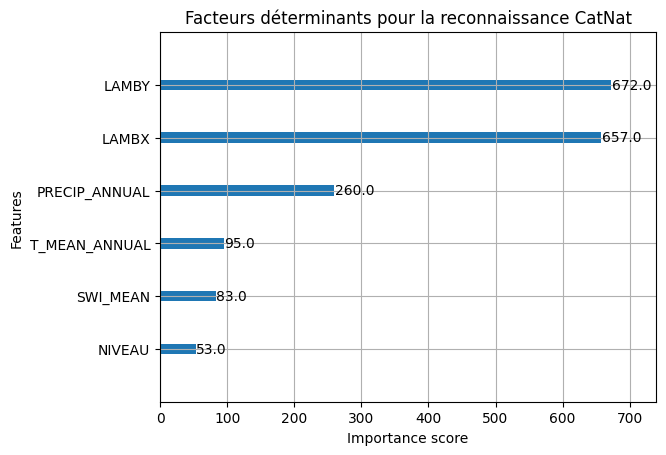

In [7]:
import matplotlib.pyplot as plt
# 1. Création d'un DataFrame de résultats sur le jeu de test
analyse_erreurs = X_test.copy()
analyse_erreurs['Reel'] = y_test
analyse_erreurs['Prediciton'] = y_pred
analyse_erreurs['Probabilite'] = y_proba # Score de confiance du modèle

# 2. Identification des "Faux Positifs" (Les communes "Oubliées")
# Le modèle prédit une CatNat (conditions réunies) mais il n'y a pas eu d'arrêté.
faux_positifs = analyse_erreurs[(analyse_erreurs['Reel'] == 0) & (analyse_erreurs['Prediciton'] == 1)]

# 3. Identification des "Faux Négatifs" (Les "Inattendues")
# Il y a eu un arrêté mais le modèle ne l'avait pas prédit.
faux_negatifs = analyse_erreurs[(analyse_erreurs['Reel'] == 1) & (analyse_erreurs['Prediciton'] == 0)]

print(f"Nombre de Faux Positifs (Oubliées) : {len(faux_positifs)}")
print(f"Nombre de Faux Négatifs (Inattendues) : {len(faux_negatifs)}")

# 4. Importance des variables : Qu'est-ce qui a le plus compté ?
xgb.plot_importance(model_catnat, max_num_features=10)
plt.title("Facteurs déterminants pour la reconnaissance CatNat")
plt.show()

L'importance prédominante des coordonnées géographiques (LAMBX et LAMBY) souligne que la localisation spatiale est le facteur le plus déterminant pour obtenir un arrêté de catastrophe naturelle, devant même les indicateurs climatiques bruts. Par ailleurs, l'évolution du SWI confirme que les sols les plus argileux (NIVEAU 3.0) subissent un stress hydrique plus sévère et persistant, atteignant des seuils critiques durant la période estivale.